# Chapter 5 — Birth of the Resistance Strain Gage

*A deformation of a thousandth changes a resistance by two parts in a thousand — and that tiny, faithful ratio is the whole invention.*

Companion notebook to Chapter 5 — Birth of the Resistance Strain Gage.

The first practical resistance strain gages were developed independently by Edward Simmons at Caltech and Arthur Ruge at MIT in 1938. Both used fine resistance wire bonded to a backing material and cemented to a test specimen — the same basic configuration that, in foil form, is still used today. The key that made the gage practical was the *gage factor*: the proportionality between fractional resistance change and mechanical strain. For constantan alloy, GF ≈ 2.0, meaning a 1000 microstrain deformation produces a 0.2% change in resistance.

That 0.2% change is small. At 350 Ω — a common gage resistance — 1000 με produces a resistance change of just 0.70 Ω: a change of two parts in a thousand that has to be resolved cleanly against the full 350 Ω baseline. Measuring it accurately requires a *Wheatstone bridge* circuit, precision excitation, and careful attention to lead wire resistance, contact resistance, and temperature effects. The gage factor is the pivot between the mechanical world (how much did this deform?) and the electrical world (how much did the resistance change?), and it is the number that every manufacturer must accurately characterize and certify for each gage lot.

The relationship ΔR/R = GF·ε is linear and holds well across the elastic range of most engineering materials. The bridge output V_out ≈ V_ex · GF · ε / 4 follows directly, giving the complete signal chain from mechanical strain to electrical output in a single expression. This notebook makes the relationship concrete with realistic values.

**This notebook demonstrates:**
1. Resistance change and quarter-bridge output vs. strain for a 350 Ω gage (GF = 2.00, V_ex = 5 V) from 0 to 3000 με

In [1]:
# !pip install numpy matplotlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# Figures are written here; the book includes this exact path — do not rename it.
OUT_DIR = Path("../src/media/ch05")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — Gage Factor: Resistance Change and Bridge Output vs. Strain

The gage factor GF is defined as the fractional resistance change per unit strain: GF = (ΔR/R) / ε. For constantan (the most common foil gage alloy), GF ≈ 2.0. This means a 1000 με deformation changes a 350 Ω gage resistance by 0.2% — about 0.70 Ω, a shift of just two parts in a thousand riding on top of the full 350 Ω. Resolving that small change cleanly is the central challenge of strain gage instrumentation.

The two panels show the complete signal chain from mechanical strain to electrical output. The left panel shows resistance change ΔR vs. strain — a straight line with slope GF·Rg. The right panel shows the quarter-bridge output voltage vs. strain — a straight line with slope V_ex·GF/4. At 1000 με with GF = 2.00 and V_ex = 5 V, the bridge output is 2.50 mV: small enough to require amplification and careful noise management, but large enough to measure precisely with a 16-bit ADC.

The printed numerical summary at the bottom reports the exact values at 1000 με — resistance change in milliohms and as a fraction of Rg, and bridge output in millivolts and mV/V. These are the numbers to check when setting up a new installation: they tell you whether the amplifier gain and ADC full-scale range are matched to the expected signal level.

$$GF = \frac{\Delta R / R}{\varepsilon}$$

In words: the gage factor is how many percent the resistance changes for each unit of strain. GF ≈ 2.0–2.1 for constantan alloy (most foil gages). Semiconductor gages can reach GF = 100–150 at the cost of strong temperature dependence.

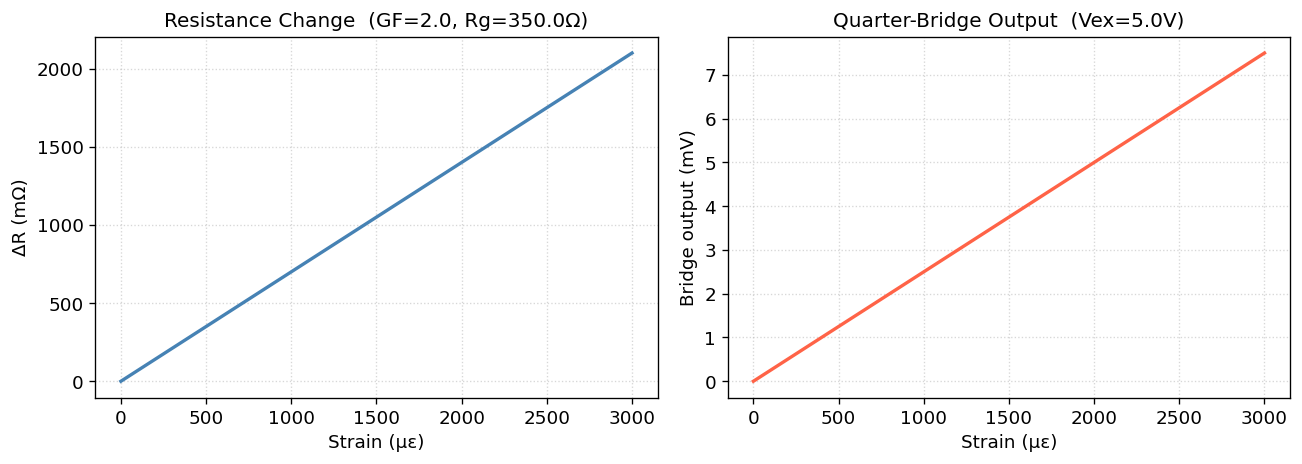

At ε = 1000 με:  ΔR = 700.00 mΩ  (0.2000% of Rg)
Quarter-bridge output ≈ 2.500 mV  (0.500 mV/V)


In [2]:
# --- Gage and bridge parameters ---
GF  = 2.00     # gage factor (round value; real constantan foil runs 2.05–2.10)
RG  = 350.0    # unstrained gage resistance (Ω)
VEX = 5.0      # bridge excitation voltage (V)

# --- Strain sweep ---
EPS_MAX  = 3000e-6   # largest strain to plot (3000 με)
N_POINTS = 300       # samples across the sweep
EPS_TEST = 1000e-6   # reference strain for the printed summary (1000 με)


def resistance_change(strain, gf=GF, Rg=RG):
    """Return the gage resistance change ΔR (Ω): ΔR = GF · Rg · ε."""
    return gf * Rg * strain


def quarter_bridge_output(strain, gf=GF, Vex=VEX):
    """Return the quarter-bridge output voltage (V), linear approximation V = Vex · GF · ε / 4."""
    return Vex * gf * strain / 4.0


eps_range = np.linspace(0, EPS_MAX, N_POINTS)
dR        = resistance_change(eps_range)
Vout_qb   = quarter_bridge_output(eps_range)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(eps_range * 1e6, dR * 1000, 'steelblue', lw=2)
axes[0].set_xlabel('Strain (με)'); axes[0].set_ylabel('ΔR (mΩ)')
axes[0].set_title(f'Resistance Change  (GF={GF}, Rg={RG}Ω)')
axes[0].grid(True, linestyle=':', alpha=0.5)

axes[1].plot(eps_range * 1e6, Vout_qb * 1000, 'tomato', lw=2)
axes[1].set_xlabel('Strain (με)'); axes[1].set_ylabel('Bridge output (mV)')
axes[1].set_title(f'Quarter-Bridge Output  (Vex={VEX}V)')
axes[1].grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig05_nb1_resistance_change_strain.png', bbox_inches='tight', dpi=300)
plt.show()

dR_test   = resistance_change(EPS_TEST)
Vout_test = quarter_bridge_output(EPS_TEST)
print(f"At ε = 1000 με:  ΔR = {dR_test*1000:.2f} mΩ  ({dR_test/RG*100:.4f}% of Rg)")
print(f"Quarter-bridge output ≈ {Vout_test*1000:.3f} mV  ({Vout_test/VEX*1000:.3f} mV/V)")

---
## Where to take this next

The single relationship above is the seed for almost everything the rest of the book develops. A few concrete extensions:

1. **Constantan vs. semiconductor.** Overlay a second quarter-bridge curve using GF = 150 for a silicon gage on the same axes. You will see the enormous sensitivity advantage at a glance — then read Chapter 23 to understand why that gain is paid for with strong temperature dependence and nonlinearity.
2. **Expose the linearity assumption.** The quarter-bridge formula used here is the linear approximation. Add the exact expression, V_out = (V_ex/4) · (ΔR/R) / (1 + (ΔR/R)/2), and plot the percentage error against the linear line out to 3000 με. This quantifies exactly when the convenient `/4` shortcut starts to lie.
3. **Add the leads.** Introduce a lead-wire resistance R_L in series with the gage and recompute the effective gage factor. This is the desensitization problem that motivated three-wire hookups — the practical wiring detail that Simmons's and Ruge's successors had to solve to make the gage a field instrument.